In [1]:
!unzip StyleSense.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/StyleSense/images/hats_headwear/f24a29418b56966848ca68dfd8187c52.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f259d12e8f54eb9e0d7dd8e765660086.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f25bbff33a9e9f544ea353d072455baf.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f25ddf3a937bc638bddf46b5253cd54a.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f269077abdc296cf13345b3080c289ce.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f2784e39a7888726e2303550c0f956f0.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f280317f81835890129533c31daee5ea.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f3472505c13d3e0f05ebc65ca15edb40.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f3b93e83ad45e4f7cc4edee43a3acb67.jpg  
  inflating: /content/StyleSense/images/hats_headwear/f3ee354e0bda2b258c922cfb7480938e.jpg  
  inflating: /conte

In [2]:
!ls /content/

sample_data  StyleSense  StyleSense.zip


In [3]:
!ls /content/StyleSense/

final_dataset.csv  images  model_A.py


In [4]:
!pip install transformers -q

In [5]:
%cd /content/StyleSense
!python model_A.py

/content/StyleSense
Using device: cuda
Dataset size: 4724 samples
Classes (5): ['hats_headwear', 'pants_trousers', 'shoes', 'shorts', 'tshirts_tops']
Train: 3306 | Val: 709 | Test: 709
Loading BERT tokenizer...
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 194kB/s]
vocab.txt: 232kB [00:00, 2.00MB/s]
tokenizer.json: 466kB [00:00, 3.70MB/s]
DataLoaders ready | Train: 207 batches | Val: 45 batches | Test: 45 batches
Loading BERT model...
config.json: 100% 570/570 [00:00<00:00, 2.45MB/s]
model.safetensors: 100% 440M/440M [00:02<00:00, 162MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 903.48it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |

In [13]:
from google.colab import files
uploaded = files.upload()

Saving 1.png to 1 (2).png
Saving 2.png to 2 (1).png
Saving 3.png to 3 (1).png
Saving 4.png to 4 (1).png
Saving 5.png to 5 (1).png
Saving 6.png to 6 (1).png
Saving 7.png to 7.png
Saving 8.png to 8.png
Saving 9.png to 9.png
Saving 10.png to 10.png


In [18]:
%cd /content/StyleSense
import json
import torch
from PIL import Image
from torchvision import transforms
from transformers import BertTokenizer, BertModel
import torch.nn as nn
from torchvision import models as tv_models

# Load label map
with open("model_A_outputs/label_map.json") as f:
    maps = json.load(f)
id2label = {int(k): v for k, v in maps["id2label"].items()}
num_classes = len(id2label)

# Rebuild model
class MultimodalFashionClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        efficientnet = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.DEFAULT)
        self.image_encoder = nn.Sequential(*list(efficientnet.children())[:-1])
        self.fusion = nn.Sequential(
            nn.Linear(768 + 1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, input_ids, attention_mask, image):
        text_feat = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        img_feat  = self.image_encoder(image).flatten(1)
        return self.fusion(torch.cat([text_feat, img_feat], dim=1))

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = MultimodalFashionClassifier(num_classes).to(DEVICE)
model.load_state_dict(torch.load("model_A_outputs/trained_model_A.pth", map_location=DEVICE))
model.eval()
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print("Model loaded!")

/content/StyleSense


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [19]:
def predict(text, image_path):
    encoding = tokenizer(text, max_length=128, padding="max_length", truncation=True, return_tensors="pt")
    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)
    image = Image.open(image_path).convert("RGB")
    image = eval_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(input_ids, attention_mask, image)
    return id2label[logits.argmax(dim=1).item()]

test_cases = [
    ("1.png",  "Nike running sneakers athletic shoes"),
    ("2.png",  "Adidas black training shoes sneakers"),
    ("3.png",  "black sport shoes running footwear"),
    ("4.png",  "New Balance white sneakers shoes"),
    ("5.png",  "Nike Jordan black white sneakers"),
    ("6.png",  "New Balance grey running shoes"),
    ("7.png",  "black t-shirt short sleeve crew neck top"),
    ("8.png",  "Celine black t-shirt short sleeve top"),
    ("9.png",  "navy blue graphic t-shirt love print top"),
    ("10.png", "white plain t-shirt short sleeve top"),
]

expected = ["shoes","shoes","shoes","shoes","shoes","shoes",
            "tshirts_tops","tshirts_tops","tshirts_tops","tshirts_tops"]

print("Image   | Predicted      | Expected        | Status")
print("-" * 60)
for (img, txt), exp in zip(test_cases, expected):
    pred = predict(txt, img)
    status = "correct" if pred == exp else "WRONG"
    print(f"{img:8} | {pred:15} | {exp:15} | {status}")

Image   | Predicted      | Expected        | Status
------------------------------------------------------------
1.png    | shoes           | shoes           | correct
2.png    | shoes           | shoes           | correct
3.png    | shoes           | shoes           | correct
4.png    | shoes           | shoes           | correct
5.png    | shoes           | shoes           | correct
6.png    | shoes           | shoes           | correct
7.png    | tshirts_tops    | tshirts_tops    | correct
8.png    | tshirts_tops    | tshirts_tops    | correct
9.png    | tshirts_tops    | tshirts_tops    | correct
10.png   | tshirts_tops    | tshirts_tops    | correct


In [20]:
pred = predict("Nike running sneakers athletic shoes", "1.png")
print(f"Image correct + Text correct: {pred}")

Image correct + Text correct: shoes


In [21]:
pred = predict("black t-shirt short sleeve top", "1.png")
print(f"Image correct + Text WRONG: {pred}")

Image correct + Text WRONG: tshirts_tops


In [23]:
pred = predict("", "10.png")
print(f"Image only (no text): {pred}")

Image only (no text): tshirts_tops


In [24]:
from google.colab import files
files.download("model_A_outputs/trained_model_A.pth")
files.download("model_A_outputs/evaluation_results_A.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

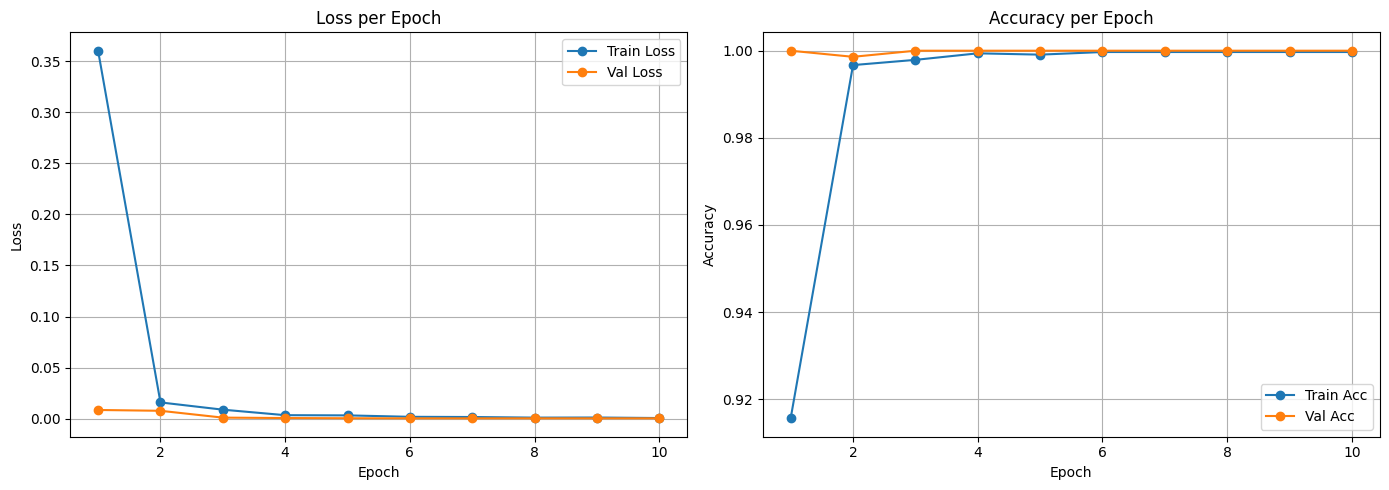

Plot saved!


In [25]:
import json
import matplotlib.pyplot as plt

with open("model_A_outputs/training_history.json") as f:
    history = json.load(f)

epochs     = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss   = [h["val_loss"] for h in history]
train_acc  = [h["train_acc"] for h in history]
val_acc    = [h["val_acc"] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, train_loss, label="Train Loss", marker="o")
ax1.plot(epochs, val_loss,   label="Val Loss",   marker="o")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epochs, train_acc, label="Train Acc", marker="o")
ax2.plot(epochs, val_acc,   label="Val Acc",   marker="o")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("model_A_outputs/training_plot.png", dpi=150)
plt.show()
print("Plot saved!")

In [26]:
from google.colab import files
files.download("model_A_outputs/training_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>